In [205]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [206]:
df = pd.read_csv('data_synthetic.csv')

X_raw = df[['Math_Score', 'English_Score']].values
y = df['Admitted'].values
y = y.reshape(-1, 1)

X_mean = np.mean(X_raw, axis=0)
X_std = np.std(X_raw, axis=0)

X_scaled = (X_raw - X_mean) / X_std

m = X_scaled.shape[0]
X = np.c_[np.ones((m, 1)), X_scaled]

In [207]:
def sigmoid(z):
    z = np.clip(z, -250, 250)
    return 1 / (1 + np.exp(-z))

In [208]:
def compute_cost(X, y, weights):
  m = X.shape[0]
  z = np.dot(X, weights)
  y_hat = sigmoid(z)

  epsilon = 1e-15

  cost = (-1 / m) * np.sum(y * np.log(y_hat + epsilon) + (1 - y) * np.log(1 - y_hat + epsilon))
  return cost

In [209]:
def gradient_descent(X, y, weights, learning_rate, epochs):
  m = X.shape[0]
  cost_history = []

  for i in range(epochs):
    z = np.dot(X, weights)
    y_hat = sigmoid(z)

    gradient = (1 / m) * np.dot(X.T, (y_hat - y))
    weights -= learning_rate * gradient

    cost = compute_cost(X, y, weights)
    cost_history.append(cost)

    if i % 100 == 0:
        print(f'Epoch {i}: Cost = {cost:.4f}')

  return weights, cost_history

In [210]:
n_features = X.shape[1]

initial_weights = np.zeros((n_features, 1))

learning_rate = 0.01
epochs = 10000
optimized_weights, history = gradient_descent(X, y, initial_weights, learning_rate, epochs)
print(optimized_weights)

Epoch 0: Cost = 0.6899
Epoch 100: Cost = 0.4641
Epoch 200: Cost = 0.3536
Epoch 300: Cost = 0.2908
Epoch 400: Cost = 0.2507
Epoch 500: Cost = 0.2228
Epoch 600: Cost = 0.2023
Epoch 700: Cost = 0.1866
Epoch 800: Cost = 0.1741
Epoch 900: Cost = 0.1639
Epoch 1000: Cost = 0.1554
Epoch 1100: Cost = 0.1482
Epoch 1200: Cost = 0.1420
Epoch 1300: Cost = 0.1366
Epoch 1400: Cost = 0.1319
Epoch 1500: Cost = 0.1277
Epoch 1600: Cost = 0.1240
Epoch 1700: Cost = 0.1207
Epoch 1800: Cost = 0.1176
Epoch 1900: Cost = 0.1149
Epoch 2000: Cost = 0.1124
Epoch 2100: Cost = 0.1101
Epoch 2200: Cost = 0.1079
Epoch 2300: Cost = 0.1059
Epoch 2400: Cost = 0.1041
Epoch 2500: Cost = 0.1024
Epoch 2600: Cost = 0.1008
Epoch 2700: Cost = 0.0993
Epoch 2800: Cost = 0.0980
Epoch 2900: Cost = 0.0966
Epoch 3000: Cost = 0.0954
Epoch 3100: Cost = 0.0942
Epoch 3200: Cost = 0.0931
Epoch 3300: Cost = 0.0921
Epoch 3400: Cost = 0.0911
Epoch 3500: Cost = 0.0902
Epoch 3600: Cost = 0.0893
Epoch 3700: Cost = 0.0884
Epoch 3800: Cost = 0.087

In [211]:
def predict(X, weights, threshold=0.5):
    z = np.dot(X, weights)
    probabilities = sigmoid(z)

    y_pred = (probabilities >= threshold).astype(int)

    return y_pred

In [212]:
y_pred = predict(X, optimized_weights)

accuracy = np.mean(y_pred == y) * 100

print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 98.00%


Epoch 0: Cost = 0.0669
Epoch 100: Cost = 0.0667
Epoch 200: Cost = 0.0666
Epoch 300: Cost = 0.0665
Epoch 400: Cost = 0.0663
Epoch 500: Cost = 0.0662
Epoch 600: Cost = 0.0661
Epoch 700: Cost = 0.0660
Epoch 800: Cost = 0.0658
Epoch 900: Cost = 0.0657
Epoch 1000: Cost = 0.0656
Epoch 1100: Cost = 0.0655
Epoch 1200: Cost = 0.0653
Epoch 1300: Cost = 0.0652
Epoch 1400: Cost = 0.0651
Epoch 1500: Cost = 0.0650
Epoch 1600: Cost = 0.0649
Epoch 1700: Cost = 0.0648
Epoch 1800: Cost = 0.0647
Epoch 1900: Cost = 0.0646
Epoch 2000: Cost = 0.0645
Epoch 2100: Cost = 0.0644
Epoch 2200: Cost = 0.0643
Epoch 2300: Cost = 0.0642
Epoch 2400: Cost = 0.0641
Epoch 2500: Cost = 0.0640
Epoch 2600: Cost = 0.0639
Epoch 2700: Cost = 0.0638
Epoch 2800: Cost = 0.0637
Epoch 2900: Cost = 0.0636
Epoch 3000: Cost = 0.0635
Epoch 3100: Cost = 0.0634
Epoch 3200: Cost = 0.0634
Epoch 3300: Cost = 0.0633
Epoch 3400: Cost = 0.0632
Epoch 3500: Cost = 0.0631
Epoch 3600: Cost = 0.0630
Epoch 3700: Cost = 0.0629
Epoch 3800: Cost = 0.062

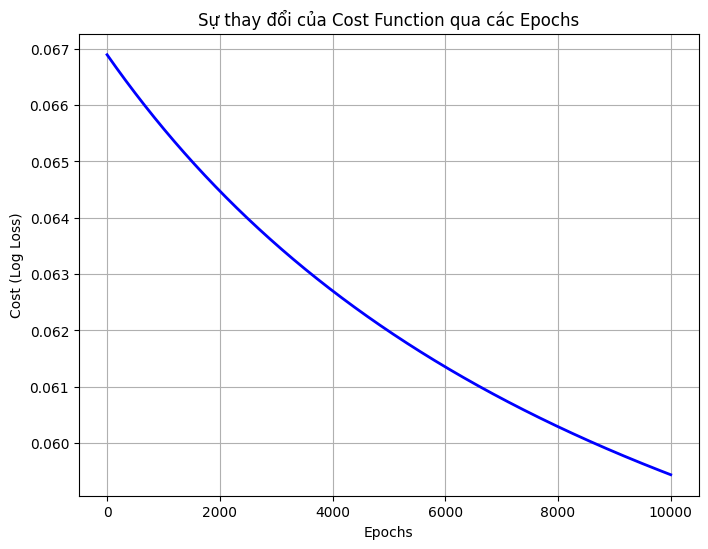

In [213]:
optimized_weights, cost_history = gradient_descent(X, y, initial_weights, learning_rate, epochs)

plt.figure(figsize=(8, 6))
plt.plot(range(len(cost_history)), cost_history, color='blue', linewidth=2)
plt.title('Sự thay đổi của Cost Function qua các Epochs')
plt.xlabel('Epochs')
plt.ylabel('Cost (Log Loss)')
plt.grid(True)
plt.show()

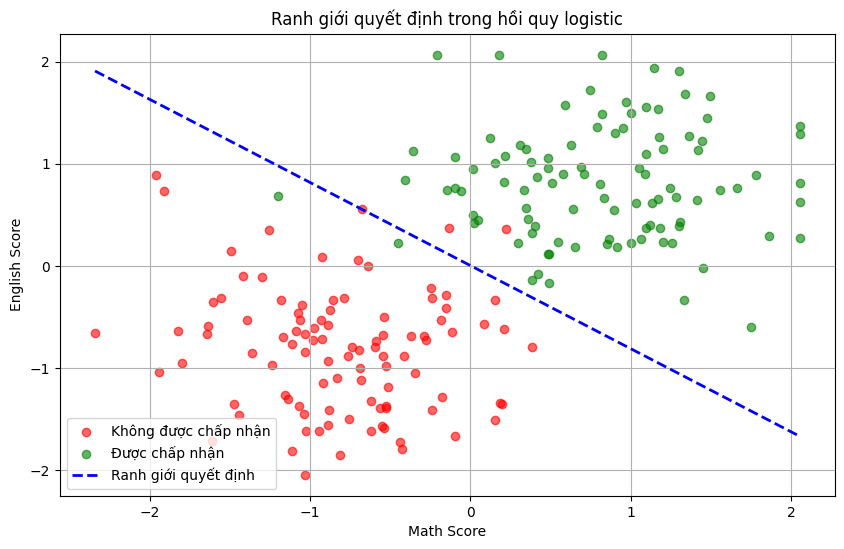

In [214]:
plt.figure(figsize=(10, 6))

plt.scatter(X_scaled[y.flatten() == 0, 0], X_scaled[y.flatten() == 0, 1], color='red', label='Không được chấp nhận', alpha=0.6)
plt.scatter(X_scaled[y.flatten() == 1, 0], X_scaled[y.flatten() == 1, 1], color='green', label='Được chấp nhận', alpha=0.6)

x1_boundary = np.array([np.min(X_scaled[:, 0]), np.max(X_scaled[:, 0])])
x2_boundary = -(optimized_weights[0] + optimized_weights[1] * x1_boundary) / optimized_weights[2]

plt.plot(x1_boundary, x2_boundary, "b--", label='Ranh giới quyết định', linewidth=2)

plt.xlabel('Math Score')
plt.ylabel('English Score')
plt.title('Ranh giới quyết định trong hồi quy logistic')
plt.legend()
plt.grid(True)
plt.show()